# 🎨 Digital Image Processing — Lab 02
## PIXEL MAGIC 🔥
### Make an Image Brighter, Darker, Stranger & Evil 👻

### Today's Mission

In Lab 01, we learned that:

> 🖼️ An image is a collection of pixels.

Today we go one step further:

> 🔢 Pixels are numbers.

So...

### What happens if we change those numbers?

Can we:
- ☀️ Make an image brighter?
- 🌙 Turn day into night?
- 💥 Increase contrast?
- 👻 Create an evil/negative image?
- 🖤 Turn a photo into black & white?
- 🌈 Create crazy colors?

Let's find out!

## 🧠 Before We Start

For an 8-bit grayscale image:

    0 ---------------------------- 255
   BLACK                         WHITE

For an RGB image:

    Pixel = [R, G, B]

Example:

    [255, 0, 0]   → 🔴 Red
    [0, 255, 0]   → 🟢 Green
    [0, 0, 255]   → 🔵 Blue
    [0, 0, 0]     → ⚫ Black
    [255,255,255] → ⚪ White

### Today's Big Idea

        Original Pixel
               ↓
        Mathematical
        Transformation
               ↓
          New Pixel

Mathematically:

                s = T(r)

where:

r = original pixel value
T = transformation
s = new pixel value

In [ ]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

In [ ]:
print("🔥 Pixel Playground is ready!")

🔥 Pixel Playground is ready!


# 📸 STEP 1 — Bring Your Image

Upload a photo.

### Recommendation:
Use a clear photo with:
- a face
- background
- both bright and dark regions

You can use your own photo.

In Colab:

📁 Files → Upload → choose your image

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving labubu.jpg to labubu.jpg


In [ ]:
filename = list(uploaded.keys())[0]

img = Image.open(filename).convert("RGB")
img_array = np.array(img)

print("Image:", filename)
print("Shape:", img_array.shape)
print("Data type:", img_array.dtype)

Image: labubu.jpg
Shape: (1500, 1500, 3)
Data type: uint8


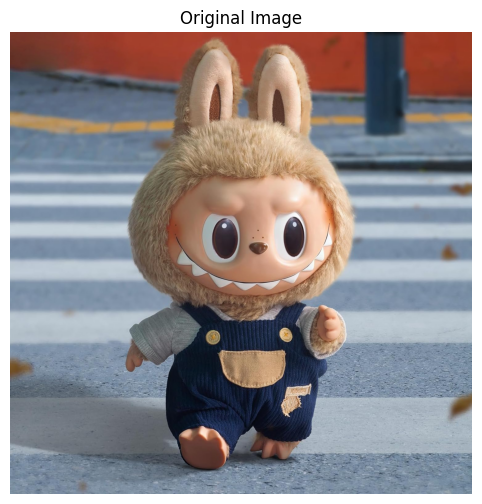

In [ ]:
# Display the original
plt.figure(figsize=(8, 6))

plt.imshow(img_array)
plt.title("Original Image")
plt.axis("off")

plt.show()

# 🔍 QUICK RECAP

Suppose:

    Shape = (600, 800, 3)

That means:

    600 → Height
    800 → Width
      3 → R, G, B

Each pixel looks like:

    [R, G, B]

For example:

    [120, 80, 200]

means:

    R = 120
    G = 80
    B = 200

Now let's start changing those numbers!

# ☀️ MISSION 1 — MAKE ME BRIGHTER

Question:

> What happens if we ADD a number to every pixel?

Suppose:

    Original pixel = 100

Add 50:

    100 + 50 = 150

The pixel becomes brighter.

Our transformation:

            s = r + C

where C is the brightness adjustment.

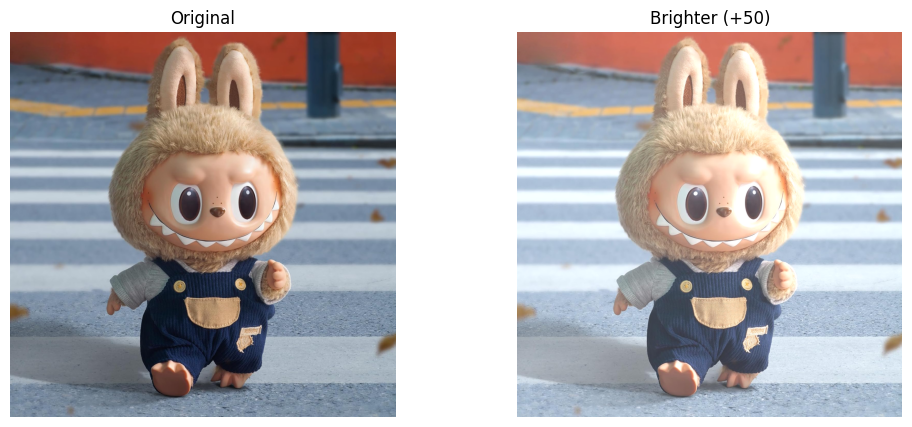

In [ ]:
brightness = 50

bright = img_array.astype(np.int16) + brightness
bright = np.clip(bright, 0, 255)
bright = bright.astype(np.uint8)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(img_array)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(bright)
plt.title("Brighter (+50)")
plt.axis("off")

plt.show()

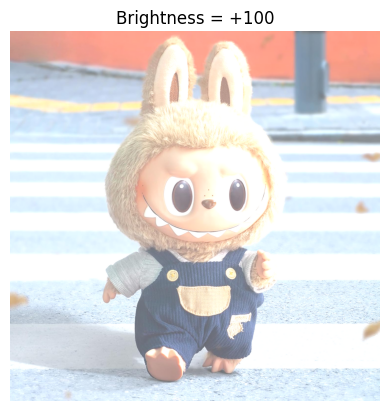

In [ ]:
# brightness =+ 100
brightness = 100

bright = img_array.astype(np.int16) + brightness
bright = np.clip(bright, 0, 255).astype(np.uint8)

plt.imshow(bright)
plt.title(f"Brightness = +{brightness}")
plt.axis("off")
plt.show()

Now, Change the brightness by yourself.
Try:
+20

*   +50
*   +25
*   +150



**Question**

What happens when:

pixel = 230
brightness = 50

Mathematically:

230 + 50 = 280

But an 8-bit pixel cannot store 280.

So what do we do?


```
np.clip(pixel, 0, 255)
```

Therefore:

280 → 255

This is called clipping.

# 🌙 MISSION 2 — TURN DAY INTO NIGHT

Instead of adding brightness...

Let's SUBTRACT.

        s = r - C

Try to make your photograph look like it was taken at night.

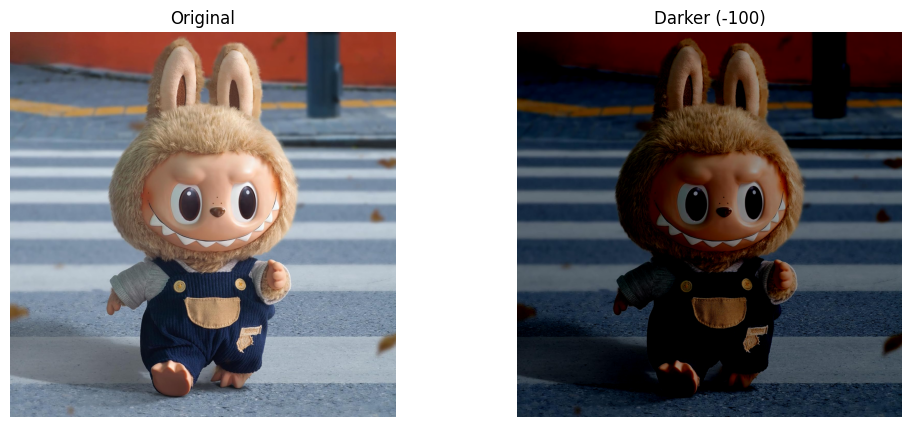

In [ ]:
darkness = 100

dark = img_array.astype(np.int16) - darkness
dark = np.clip(dark, 0, 255).astype(np.uint8)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(img_array)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(dark)
plt.title(f"Darker (-{darkness})")
plt.axis("off")

plt.show()

### 🌙 Night Mode Challenge

Try:

    darkness = 30
    darkness = 70
    darkness = 120
    darkness = 180

Which value makes the image look most like night?

# 💥 MISSION 3 — CONTRAST EXPLOSION

Brightness moves pixel values up or down.

Contrast changes the distance between pixel values.

A simple contrast transformation:

        s = αr

where:

α > 1  → increase contrast
α < 1  → decrease contrast
α = 1  → unchanged

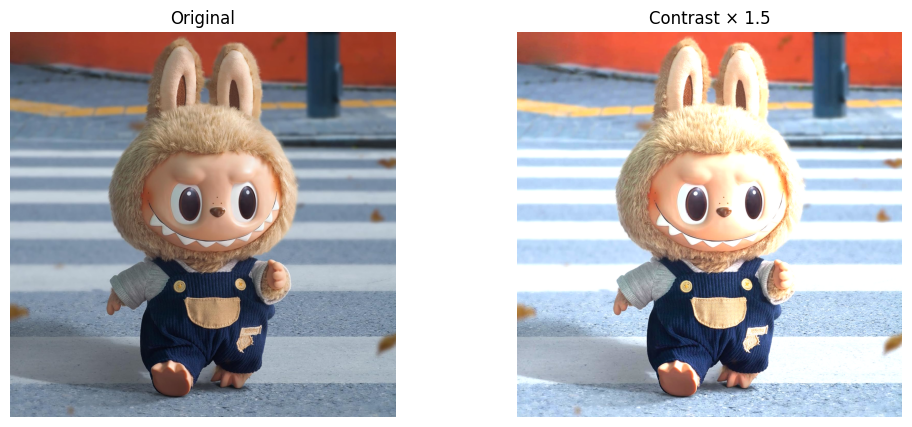

In [ ]:
alpha = 1.5

contrast = img_array.astype(np.float32) * alpha
contrast = np.clip(contrast, 0, 255).astype(np.uint8)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(img_array)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(contrast)
plt.title(f"Contrast × {alpha}")
plt.axis("off")

plt.show()

🧪 CONTRAST EXPERIMENT

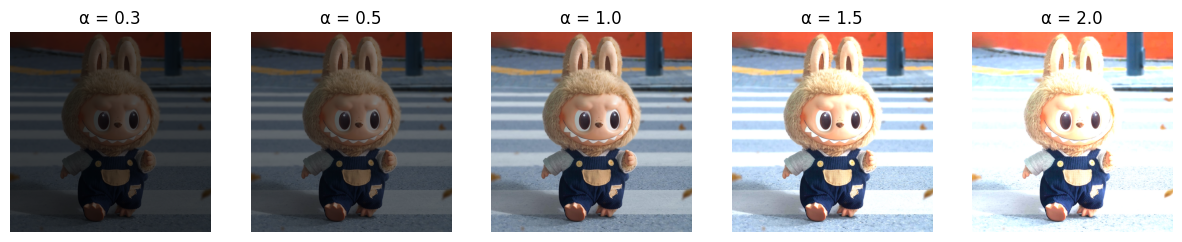

In [ ]:
alphas = [0.3, 0.5, 1.0, 1.5, 2.0]

plt.figure(figsize=(15, 8))

for i, alpha in enumerate(alphas):

    result = img_array.astype(np.float32) * alpha
    result = np.clip(result, 0, 255).astype(np.uint8)

    plt.subplot(1, len(alphas), i + 1)
    plt.imshow(result)
    plt.title(f"α = {alpha}")
    plt.axis("off")

plt.show()

# 👻 MISSION 4 — CREATE YOUR EVIL TWIN

What happens if we reverse the intensity?

For an 8-bit image:

        s = 255 - r

Examples:

    0   → 255
    50  → 205
    100 → 155
    200 → 55
    255 → 0

Black becomes white.
White becomes black.

Let's create the NEGATIVE!

/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128123 (\N{GHOST}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


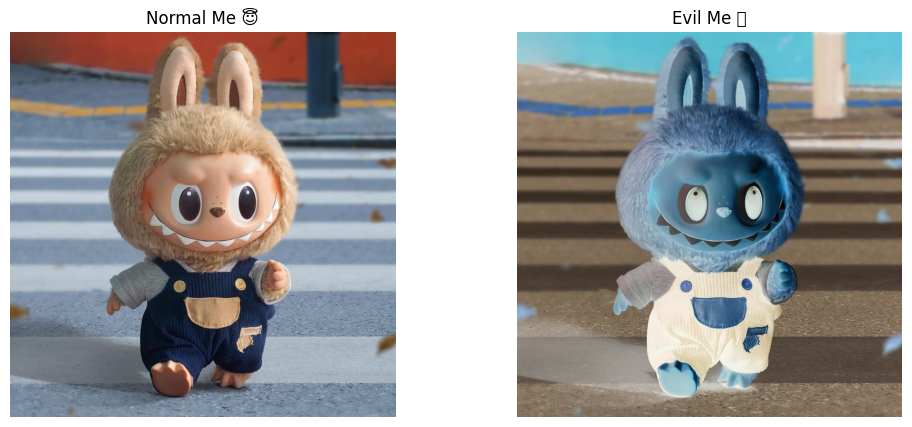

In [ ]:
negative = 255 - img_array

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(img_array)
plt.title("Normal Me 😇")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(negative)
plt.title("Evil Me 👻")
plt.axis("off")

plt.show()

## 👻 Evil Twin Challenge

Take your own photo.

Create:
1. Original
2. Negative
3. Very dark negative
4. Very bright negative

Which one looks the strangest?

# 🖤 MISSION 5 — POSTER MODE

Let's throw away most of the intensity information.

First convert the image to grayscale.

Then choose a threshold T.

If:

    pixel < T → BLACK

    pixel ≥ T → WHITE

This creates a BINARY IMAGE.

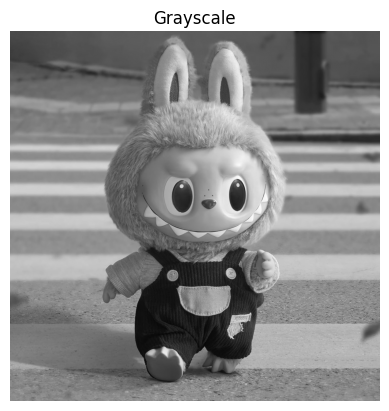

In [ ]:
gray = np.array(img.convert("L"))

plt.imshow(gray, cmap="gray")
plt.title("Grayscale")
plt.axis("off")
plt.show()

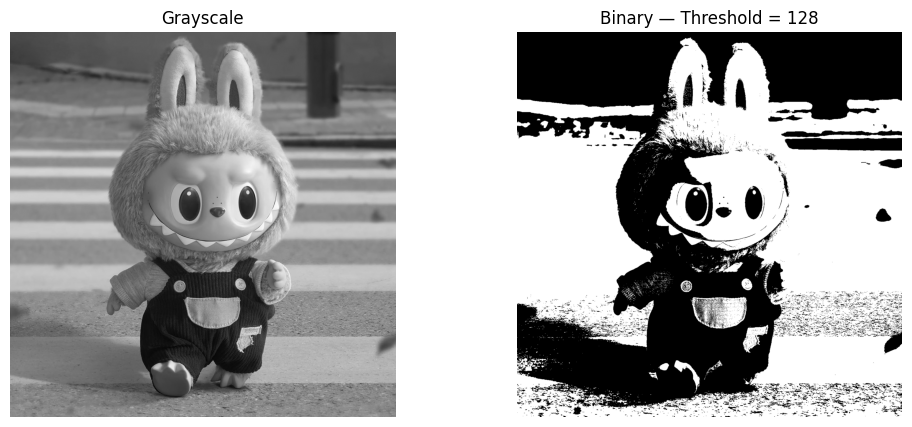

In [ ]:
threshold = 128

binary = np.where(gray >= threshold, 255, 0)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(gray, cmap="gray")
plt.title("Grayscale")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(binary, cmap="gray")
plt.title(f"Binary — Threshold = {threshold}")
plt.axis("off")

plt.show()

#🎚️ MISSION 6 — FIND THE MAGIC THRESHOLD

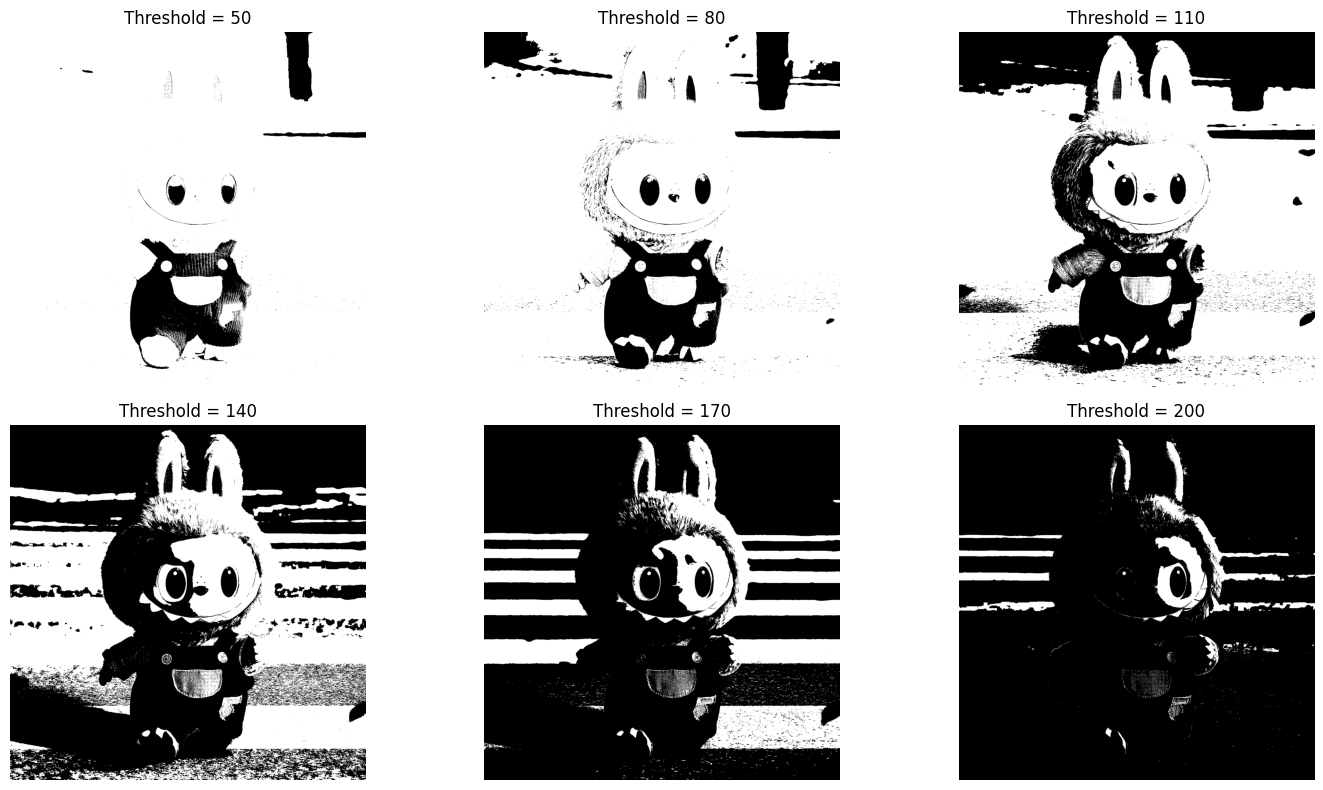

In [ ]:
thresholds = [50, 80, 110, 140, 170, 200]

plt.figure(figsize=(15, 8))

for i, t in enumerate(thresholds):

    binary = np.where(gray >= t, 255, 0)

    plt.subplot(2, 3, i + 1)
    plt.imshow(binary, cmap="gray")
    plt.title(f"Threshold = {t}")
    plt.axis("off")

plt.tight_layout()
plt.show()

##Why does the face disappear when the threshold becomes too high?

# 🌈 MISSION 7 — COLOR CHAOS

Remember:

        Pixel = [R, G, B]

What happens if we remove one channel?

Let's find out.

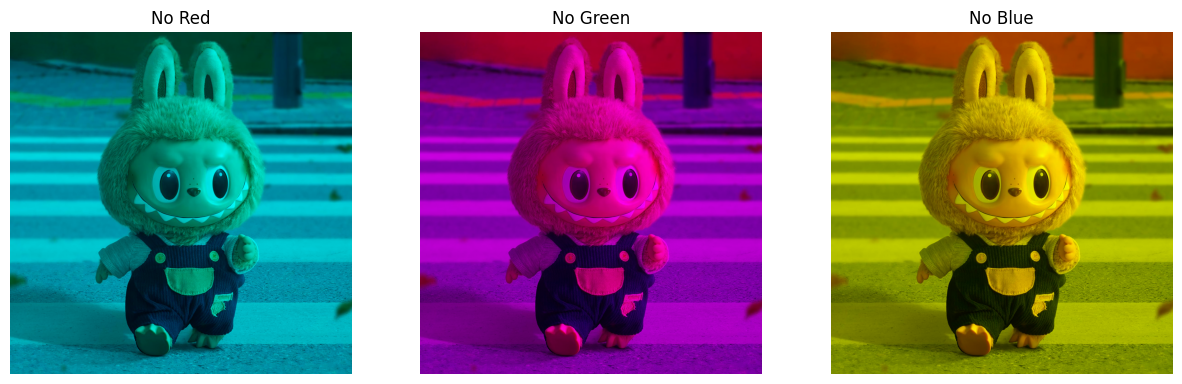

In [ ]:
no_red = img_array.copy()
no_red[:, :, 0] = 0

no_green = img_array.copy()
no_green[:, :, 1] = 0

no_blue = img_array.copy()
no_blue[:, :, 2] = 0

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(no_red)
plt.title("No Red")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(no_green)
plt.title("No Green")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(no_blue)
plt.title("No Blue")
plt.axis("off")

plt.show()

#🧪 COLOR EXPERIMENT
“There is no correct answer here. Make the ugliest image possible.”

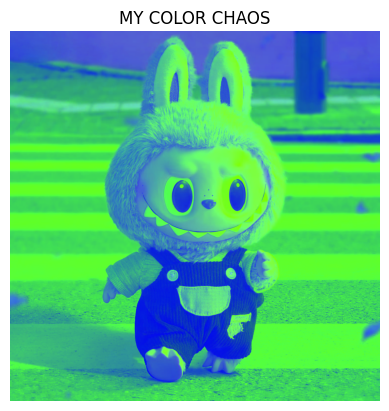

In [ ]:
custom = img_array.copy()

custom[:, :, 0] = custom[:, :, 0] * 0.5
custom[:, :, 1] = np.clip(custom[:, :, 1] * 1.5, 0, 255)
custom[:, :, 2] = 255 - custom[:, :, 2]

custom = custom.astype(np.uint8)

plt.imshow(custom)
plt.title("MY COLOR CHAOS")
plt.axis("off")
plt.show()

# 🧟 FINAL BOSS — MAKE A CURSED PHOTO

You have learned:

☀️ Brightness
🌙 Darkening
💥 Contrast
👻 Negative
🖤 Thresholding
🌈 RGB manipulation

Now combine them.

Your mission:

> Take a normal photograph and create the most ridiculous
> image possible using pixel transformations.

/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128121 (\N{JAPANESE OGRE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


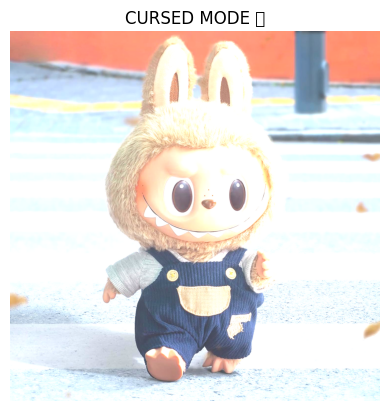

In [ ]:
cursed = img_array.astype(np.float32)

# STEP 1 — Change brightness
cursed = cursed + 40

# STEP 2 — Change contrast
cursed = cursed * 1.5

# STEP 3 — Clip values
cursed = np.clip(cursed, 0, 255)

# Convert back to image format
cursed = cursed.astype(np.uint8)

plt.imshow(cursed)
plt.title("CURSED MODE 👹")
plt.axis("off")
plt.show()

##Now change the code. Don't copy mine.

# 🧠 WHAT DID WE ACTUALLY LEARN?

Everything we did today can be written as:

                 s = T(r)

Original pixel → Transformation → New pixel

Examples:

Brightness:
        s = r + C

Darkening:
        s = r - C

Contrast:
        s = αr

Negative:
        s = 255 - r

Threshold:
        s = 0 or 255

**🏆 FINAL COMPETITION**

**PIXEL BATTLE**

Please work in pairs.

You have 10–15 minutes.

Create:

**😇 Version 1 — "Instagram Mode"**

Make the image:

brighter

clearer

higher/lower contrast


**👹 Version 2 — "Cursed Mode"**

Use at least 3 transformations.

For example:

Negative

   ↓

Contrast

   ↓

RGB manipulation

   ↓

Brightness

Then each pair displays the result.